In [81]:
#loading packeges
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime
import  seaborn as sns
import os
sns.set()

# Loading Data

In [61]:

#File paths
high_pay_data_path = './Data/cleaned_high_pay_data.csv'
shapefile_path = './us_state/us_state.shp'

# Load the high-pay data
high_pay_data = pd.read_csv(high_pay_data_path)
# Load the shapefile into a GeoDataFrame
us_states = gpd.read_file(shapefile_path)


## Define Visualization Functions
This section contains a reusable function to plot state-level maps of the United States based on specified data. The function includes options for custom color maps, labels, and scaling.


In [62]:
def StatesPlot(df, column_to_plot, cmap='viridis', label_color='black', label_size=6,
               title='United States Map', filename='us_map.png', min_value=None, max_value=None,
               edge_color='black', edge_linewidth=0.5):
    """
    Plots a US map based on state data and a specified column (e.g., income or education levels).

    Parameters:
    df (GeoDataFrame): Geodataframe containing the state geometries and data to plot.
    column_to_plot (str): Column name representing the data to be visualized (e.g., income levels, education levels).
    cmap (str): Color map to use for visualization.
    label_color (str): Color of the state labels.
    label_size (int): Font size of the state labels.
    title (str): Title of the plot.
    filename (str): Base name of the file to save the plot (without extension).
    min_value (float, optional): Minimum value to be used for color scaling.
    max_value (float, optional): Maximum value to be used for color scaling.
    edge_color (str): Color of the state borders.
    edge_linewidth (float): Width of the state borders.

    Returns:
    None
    """
    try:
        # Ensure the column exists in the dataframe
        if column_to_plot not in df.columns:
            raise ValueError(f"'{column_to_plot}' column not found in the DataFrame.")
        
        # Remove rows with missing values in the geo data
        df = df.dropna(how='any')

        # If min and max values are not provided, set them based on the column's data
        min_value = min_value or df[column_to_plot].min()
        max_value = max_value or df[column_to_plot].max()

        # Create a plot with a specified size
        fig, ax = plt.subplots(figsize=(15, 10), dpi=300)
        ax.set_axis_off()  # Hide the axis for a cleaner map view

        # Plot the state geometries using the specified column for color mapping
        df.plot(column=column_to_plot, ax=ax, alpha=0.7, cmap=cmap, linewidth=edge_linewidth, edgecolor=edge_color,
                vmin=min_value, vmax=max_value)

        # Add a color bar to represent the data values
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_value, vmax=max_value))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, aspect=10)
        cbar.set_label(column_to_plot, fontsize=12)  # Add label to the color bar

        # Add a title to the plot
        ax.set_title(title, fontsize=18, pad=15)

        # Add state labels (abbreviations) on the map
        for idx, row in df.iterrows():
            if 'STUSPS' in row and row['geometry'] is not None:
                try:
                    # Get the centroid of the state geometry
                    centroid = row['geometry'].centroid
                    # Place the state abbreviation at the centroid
                    ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=label_size, ha='center', color=label_color)
                except Exception as e:
                    print(f"Warning: Failed to label state {row.get('STUSPS', 'Unknown')} due to: {e}")

        # Ensure the Images directory exists
        os.makedirs("Images", exist_ok=True)

        # Save the plot, overwrite if necessary
        filepath = os.path.join("Images", filename)
        plt.savefig(filepath, bbox_inches='tight', dpi=300)
        print(f"Map successfully saved to {filepath}")

        # Display the plot
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")


In [ ]:
def Education_State(df, column, title, filename, cmap='tab20'):
    """
    Plots a map of the dominant education level for each state, and saves it with a unique filename.
    
    Parameters:
    df (GeoDataFrame): GeoDataFrame containing state geometries and education data.
    column (str): Column name for the data to be visualized (e.g., 'Education Level').
    cmap (str): Color map for categorical data.
    title (str): Title for the plot.
    filename (str): Base name for the file to be saved (without extension).
    
    Returns:
    None
    """
    # Set up the plot with a larger figsize for better readability
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))  # Adjusted figure size for better visibility
    
    # Remove rows with missing values in the specified column
    df = df.dropna(subset=[column])
    
    # Plot the map with the dominant education level for each state
    df.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        legend=True,
        linewidth=0.5,
        edgecolor='black',
        legend_kwds={'title': "Education Level by State"}
    )

    # Add state abbreviations to the map
    for idx, row in df.iterrows():
        centroid = row['geometry'].centroid  # Get the centroid of each state
        ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=12, ha='center', color='black')  # Adjusted fontsize for readability

    # Title for the map
    plt.title(title, fontsize=18)  # Adjusted title fontsize
    
    # Turn off axis for cleaner visualization
    plt.axis('off')
    
    # Move the legend to the best position
    ax.get_legend().set_bbox_to_anchor((1.05, 0.5))  # Adjusted legend position

    # Ensure the Images directory exists
    os.makedirs("Images", exist_ok=True)

    # Save the plot, overwrite if necessary
    filepath = os.path.join("Images", filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"Map successfully saved to {filepath}")

    # Show the plot
    plt.show()

In [ ]:
# Ensure the Images directory exists
os.makedirs("Images", exist_ok=True)

def plot_gender_distribution(df):
    """
    Plot the distribution of male and female percentages for high-paying jobs (100K+) across states.
    
    Parameters:
    df (GeoDataFrame): GeoDataFrame containing state geometries and male/female percentage data.
    """
    # Set up the plot with a significantly larger figsize to ensure the map is of an appropriate size
    fig, ax = plt.subplots(1, 1, figsize=(20, 14))  # Increase size to 20x14

    # Plot the map with male percentage using a blue color palette
    df.plot(
        column='Male_Percentage', ax=ax, cmap='Blues', linewidth=0.5, edgecolor='black', alpha=0.7
    )

    # Overlay the female percentage with a contrasting red color palette
    df.plot(
        column='Female_Percentage', ax=ax, cmap='Reds', linewidth=0.5, edgecolor='black', alpha=0.5
    )

    # Add state abbreviations to the map
    for _, row in df.iterrows():
        ax.text(
            row['geometry'].centroid.x,
            row['geometry'].centroid.y,
            row['State Abbreviation'],
            horizontalalignment='center',
            fontsize=8,
            color='black'
        )

    # Add a custom legend for Male and Female Percentages
    blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Male Percentage')
    red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Female Percentage')
    plt.legend(handles=[blue_patch, red_patch], loc='lower left', fontsize=12)

    # Title for the map
    plt.title('Distribution of Male and Female Percentages in High-Paying States ($100K+)', fontsize=18)

    # Set aspect ratio to ensure the map is not scaled incorrectly
    ax.set_aspect('equal')

    # Set plot limits to ensure it fills the figure area
    ax.set_xlim([min(df.geometry.bounds.minx), max(df.geometry.bounds.maxx)])
    ax.set_ylim([min(df.geometry.bounds.miny), max(df.geometry.bounds.maxy)])

    # Turn off axis for cleaner visualization
    plt.axis('off')

    # Save the plot with an increased bbox_inches value to ensure no cropping
    filename = "Images/Gender_distribution.png"
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=300)

    # Show the plot
    plt.show()

### Data Preparation and Plotting: High-Paying Jobs by State


#### Question1 : Which states have the highest number of high-paying jobs ($100K+ annual income)?

In [63]:
# Calculate the average annual income by state
A_income_state = (high_pay_data.groupby(['State Abbreviation'])['Annual Income']
                  .mean()
                  .reset_index()
                  .round(2))
                
# Merge the calculated annual income data with state geometries
# 'left_on' is the 'State Abbreviation' from A_income_state, and 'right_on' is the 'STUSPS' from the US states GeoDataFrame
geo_income_data = A_income_state.merge(us_states, left_on='State Abbreviation', right_on='STUSPS')

# Convert the merged DataFrame into a GeoDataFrame with spatial geometry for plotting
geo_income_data = gpd.GeoDataFrame(geo_income_data, geometry=geo_income_data.geometry)

# Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
geo_income_data = geo_income_data.loc[~geo_income_data['STUSPS'].isin(['AK', 'HI'])]


#### Visualization 

Map successfully saved to Images\Average_Highest_Income_state.png


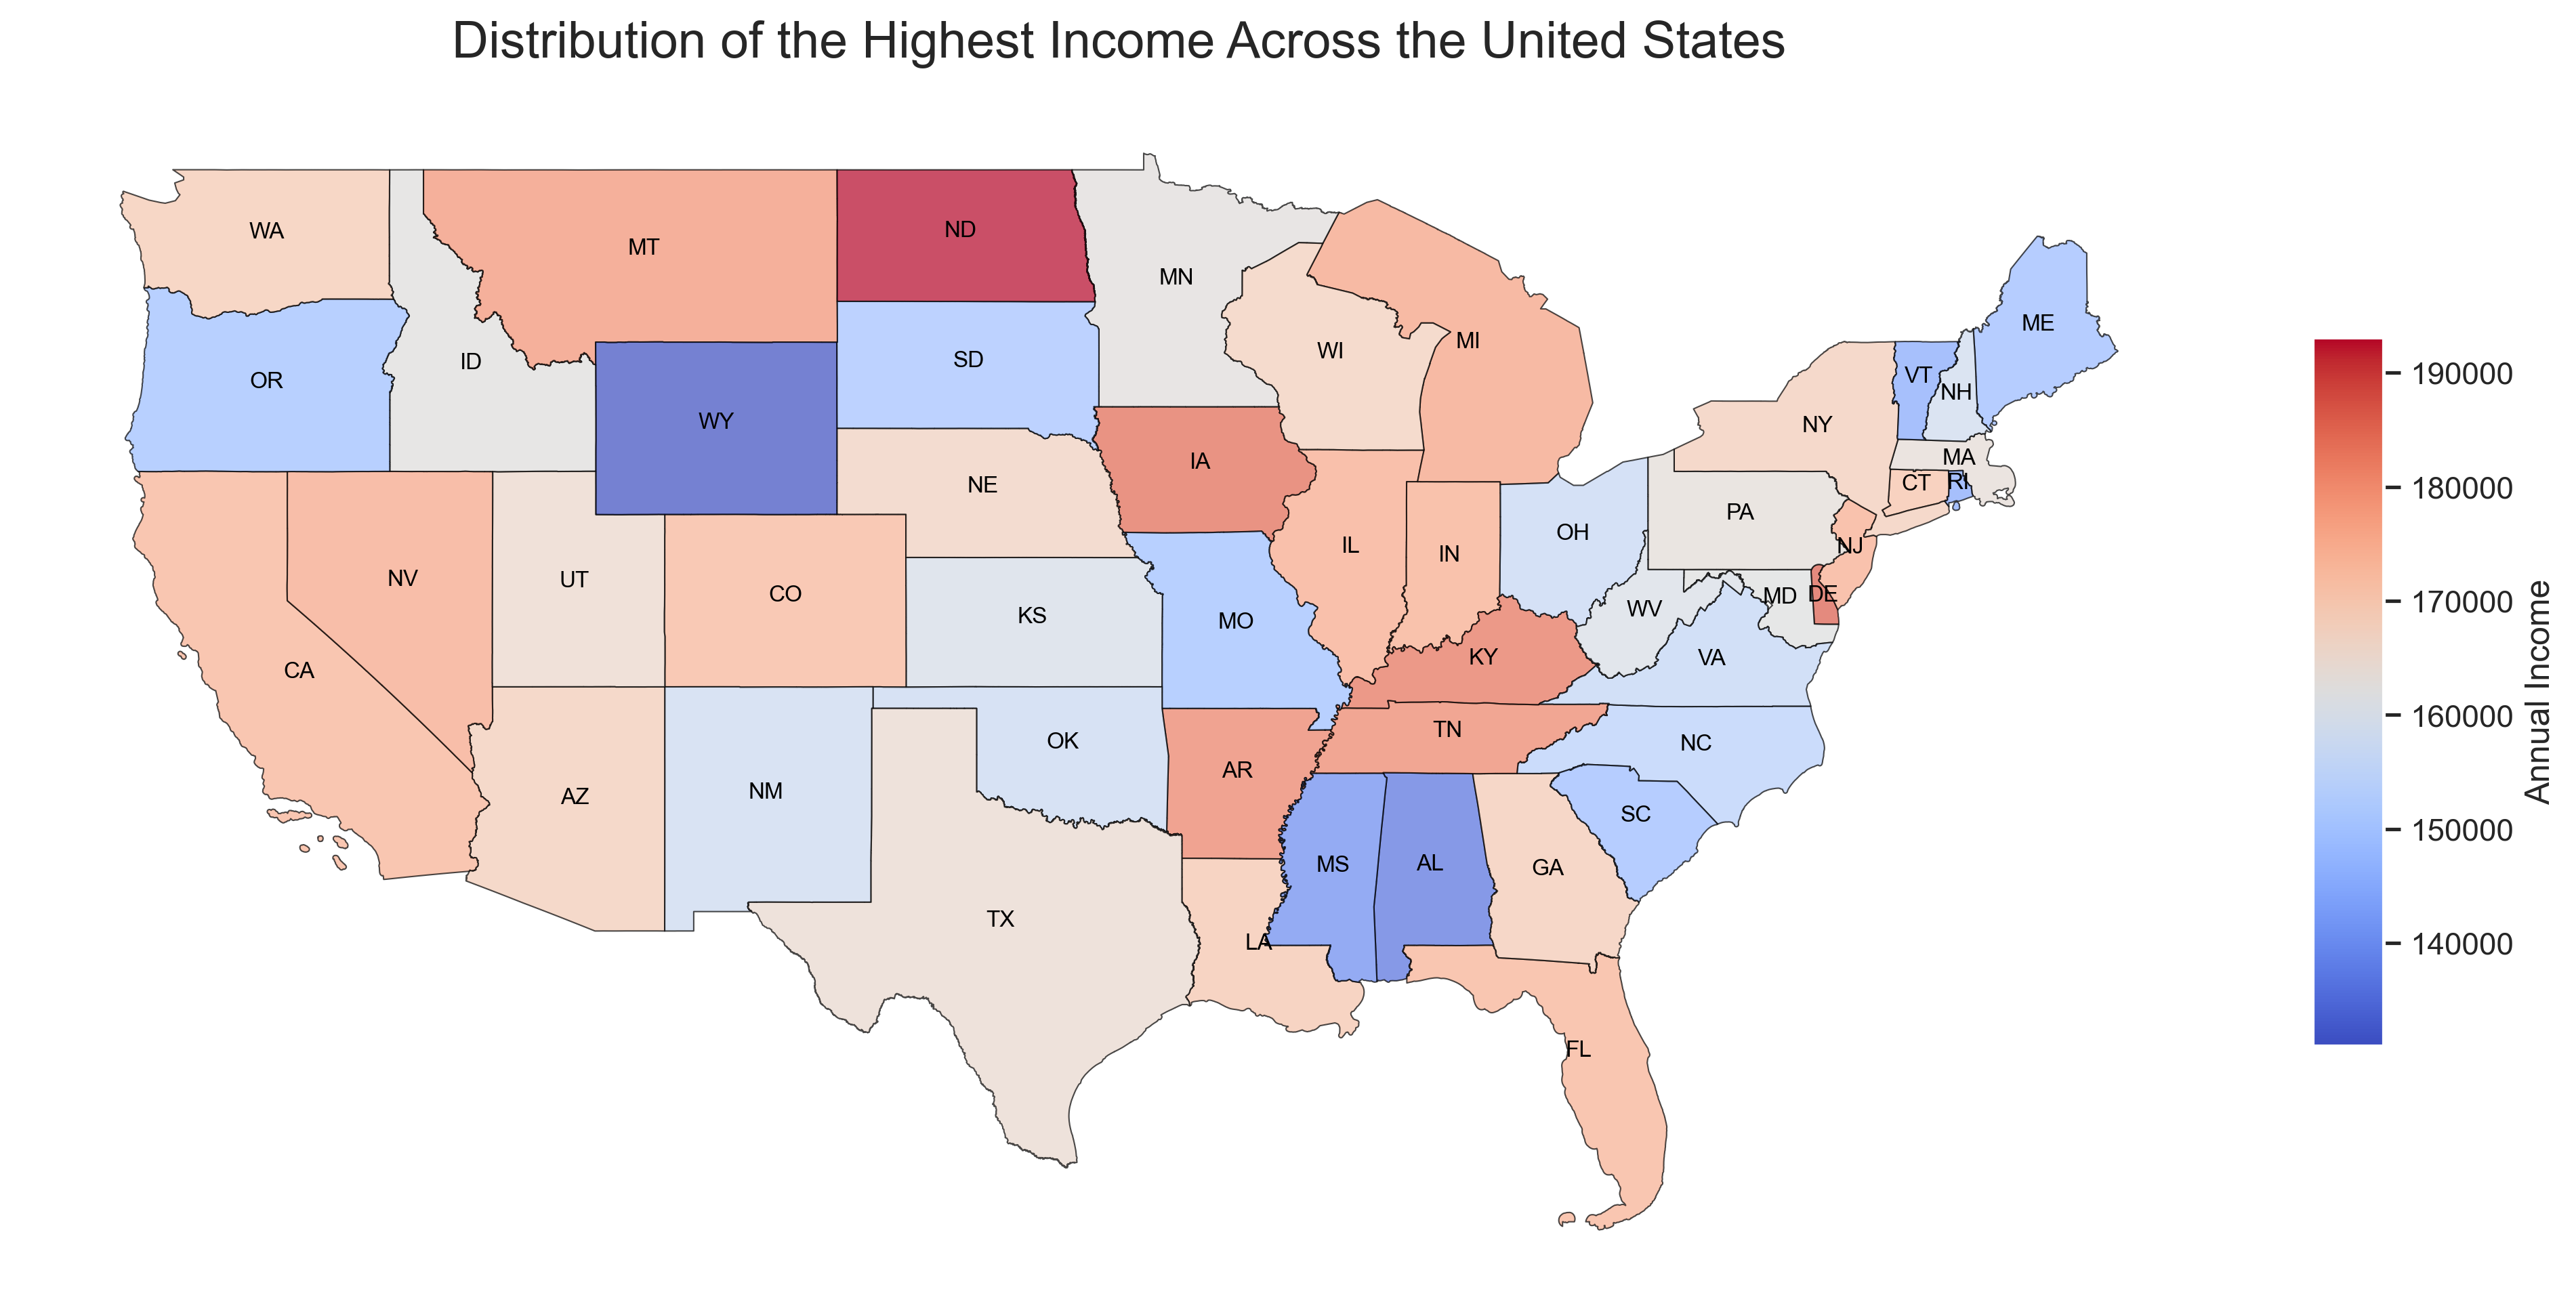

In [64]:
# Plot the data (assuming you have a plotting function defined like StatesPlot)

StatesPlot(
    df=geo_income_data,
    column_to_plot='Annual Income',
    cmap='coolwarm',  # Color map for visualization
    label_color='black',
    label_size=8,
    title='Distribution of the Highest Income Across the United States',  # Updated title
    filename='Average_Highest_Income_state.png',  # Save plot as image
    edge_color='black',
)


### Question 2: ## Which states have the highest number and the highest concentration of high-paying jobs ($100K+ annual income)?


Step 1: Aggregate High-Paying Job Data by State

In [65]:
# Aggregate high-paying jobs and total jobs by state
job_data = (
    high_pay_data.groupby('State Abbreviation')
    .agg(
        High_Paying_Jobs=('Annual Income', 'size'),
        Total_Jobs=('Employment', 'size'),
        Location_Quotient=('Location Quotient', 'mean')  # Average LQ for better representation
    )
    .reset_index()
)

# Merge with GeoDataFrame for mapping
job_data_geo = pd.merge(us_states, job_data, left_on='STUSPS', right_on='State Abbreviation', how='left')

# Convert to GeoDataFrame
job_data_geo = gpd.GeoDataFrame(job_data_geo, geometry=job_data_geo.geometry)

# Exclude Alaska (AK) and Hawaii (HI) for mapping clarity
job_data_geo = job_data_geo.loc[~job_data_geo['STUSPS'].isin(['AK', 'HI'])]


#### Visualization : 
**Step1 :** Plot High-Paying Jobs Distribution

Map successfully saved to Images\High-Paying_Jobs_Distribution.png


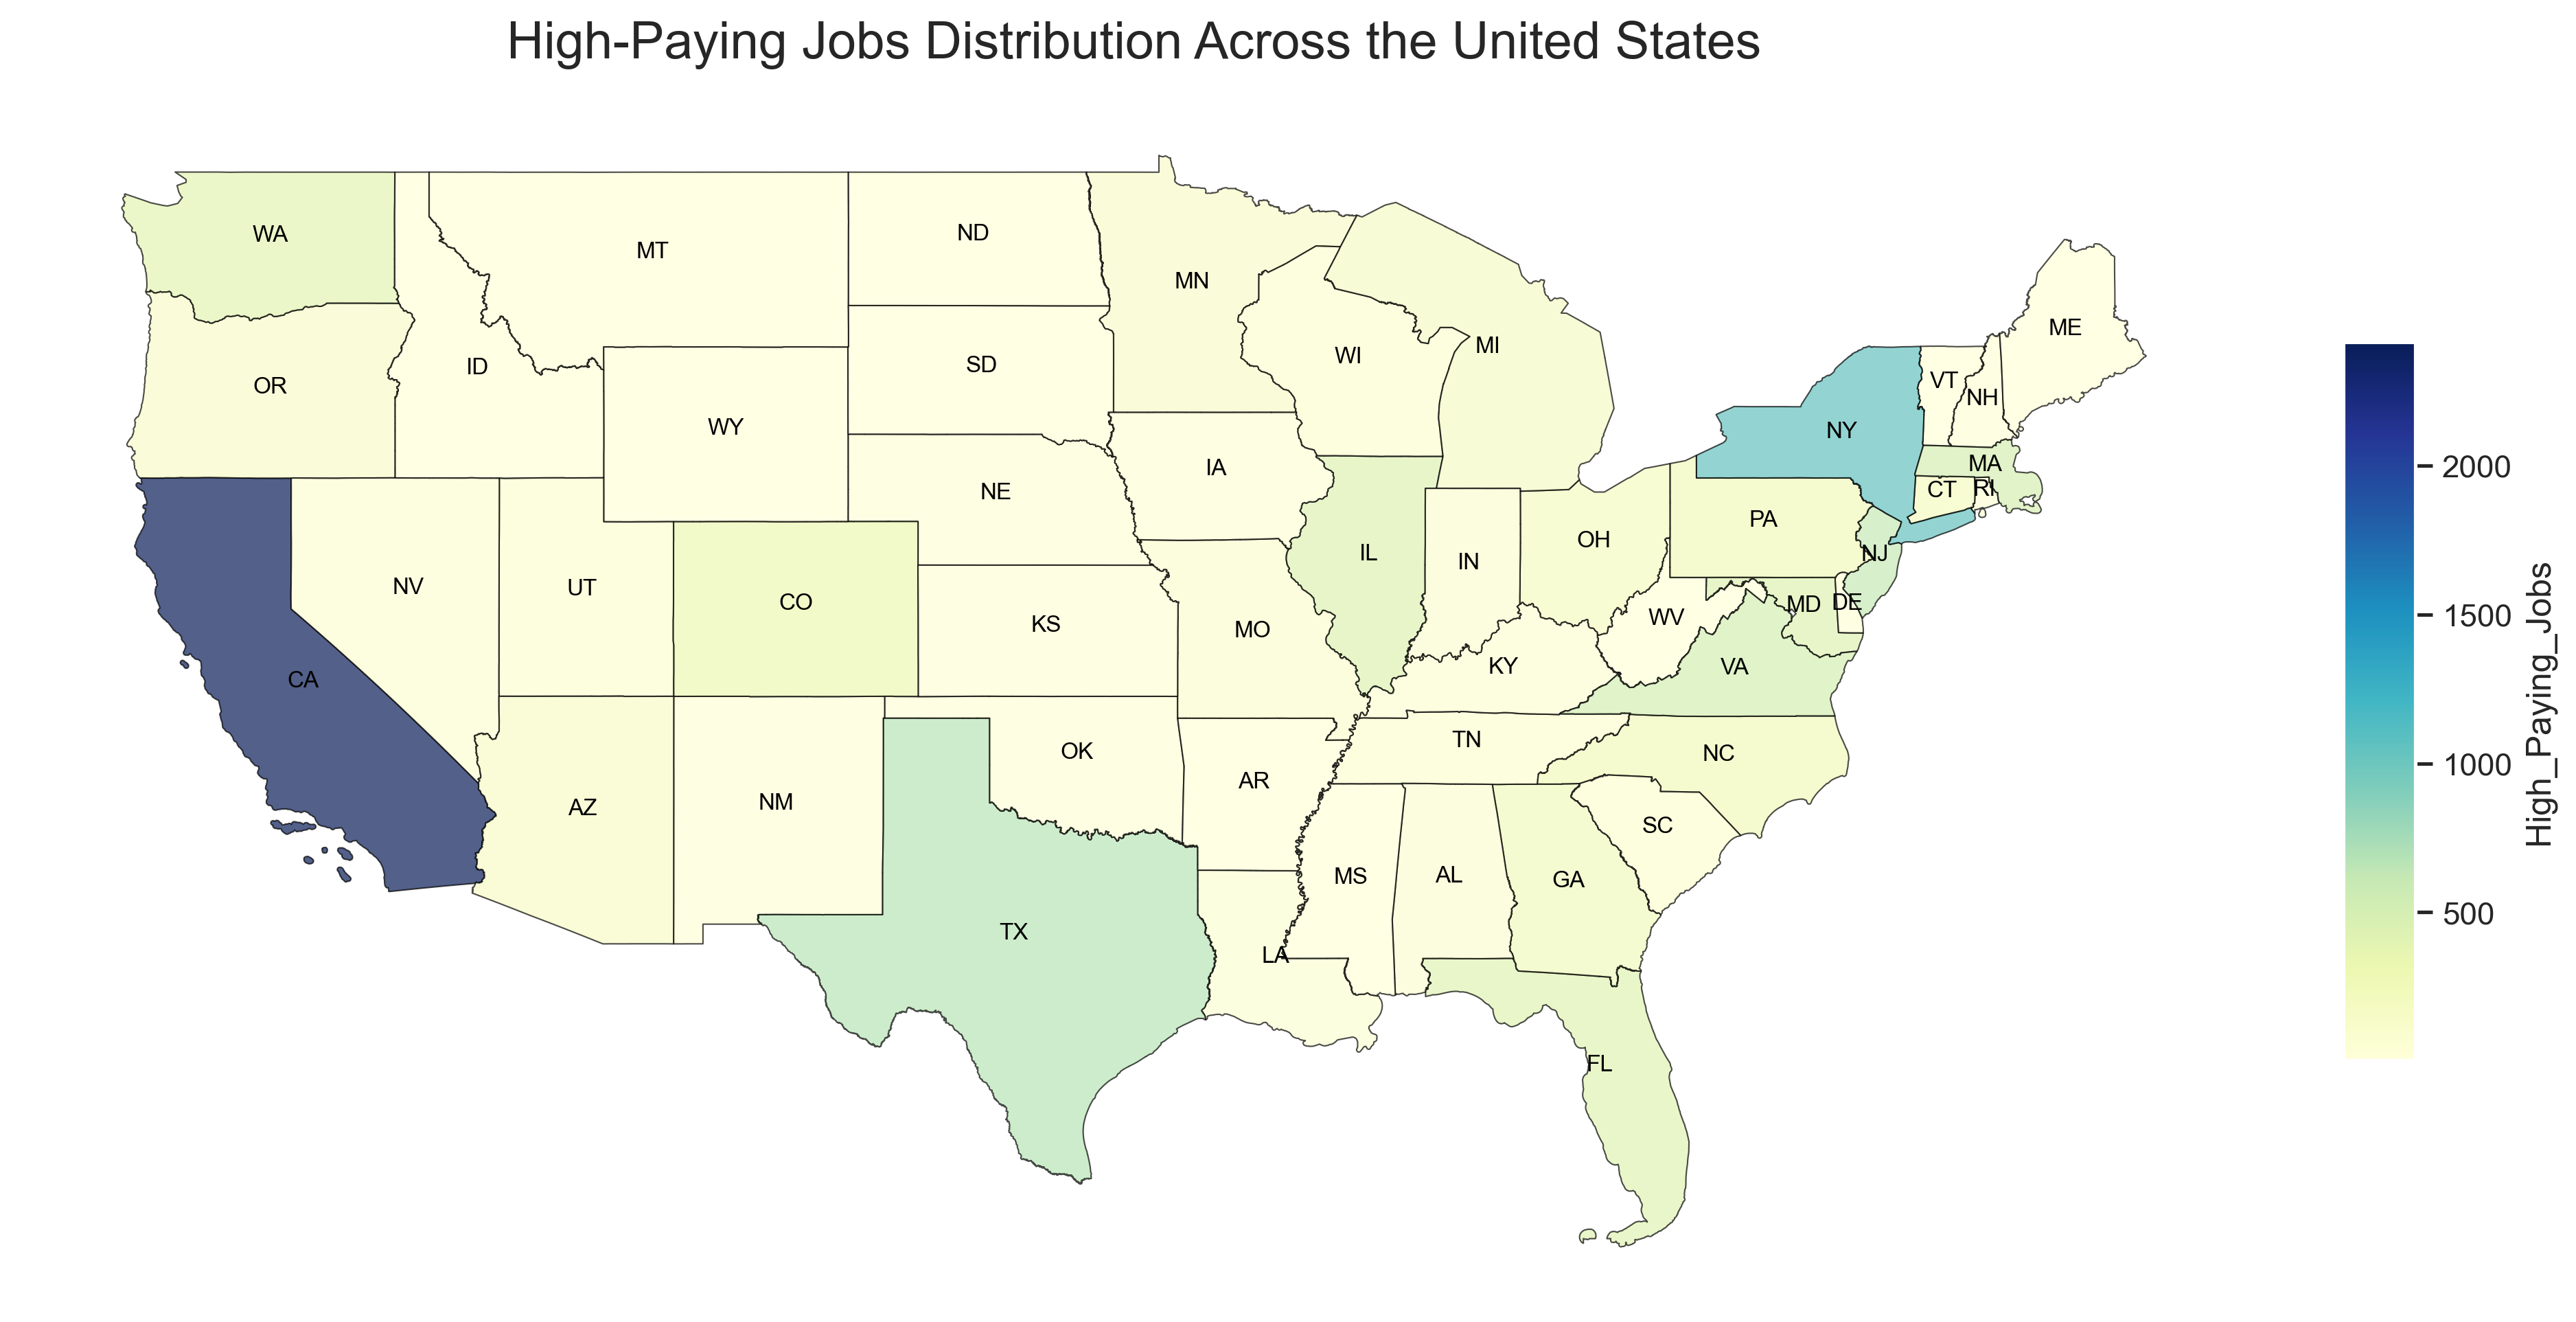

In [66]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='High_Paying_Jobs',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='High-Paying Jobs Distribution Across the United States',
    filename='High-Paying_Jobs_Distribution.png',
    edge_color='black'
)


**Step 2:** Plot Location Quotient (LQ) Distribution

Map successfully saved to Images\High_Paying_Jobs_LQ_Distribution.png


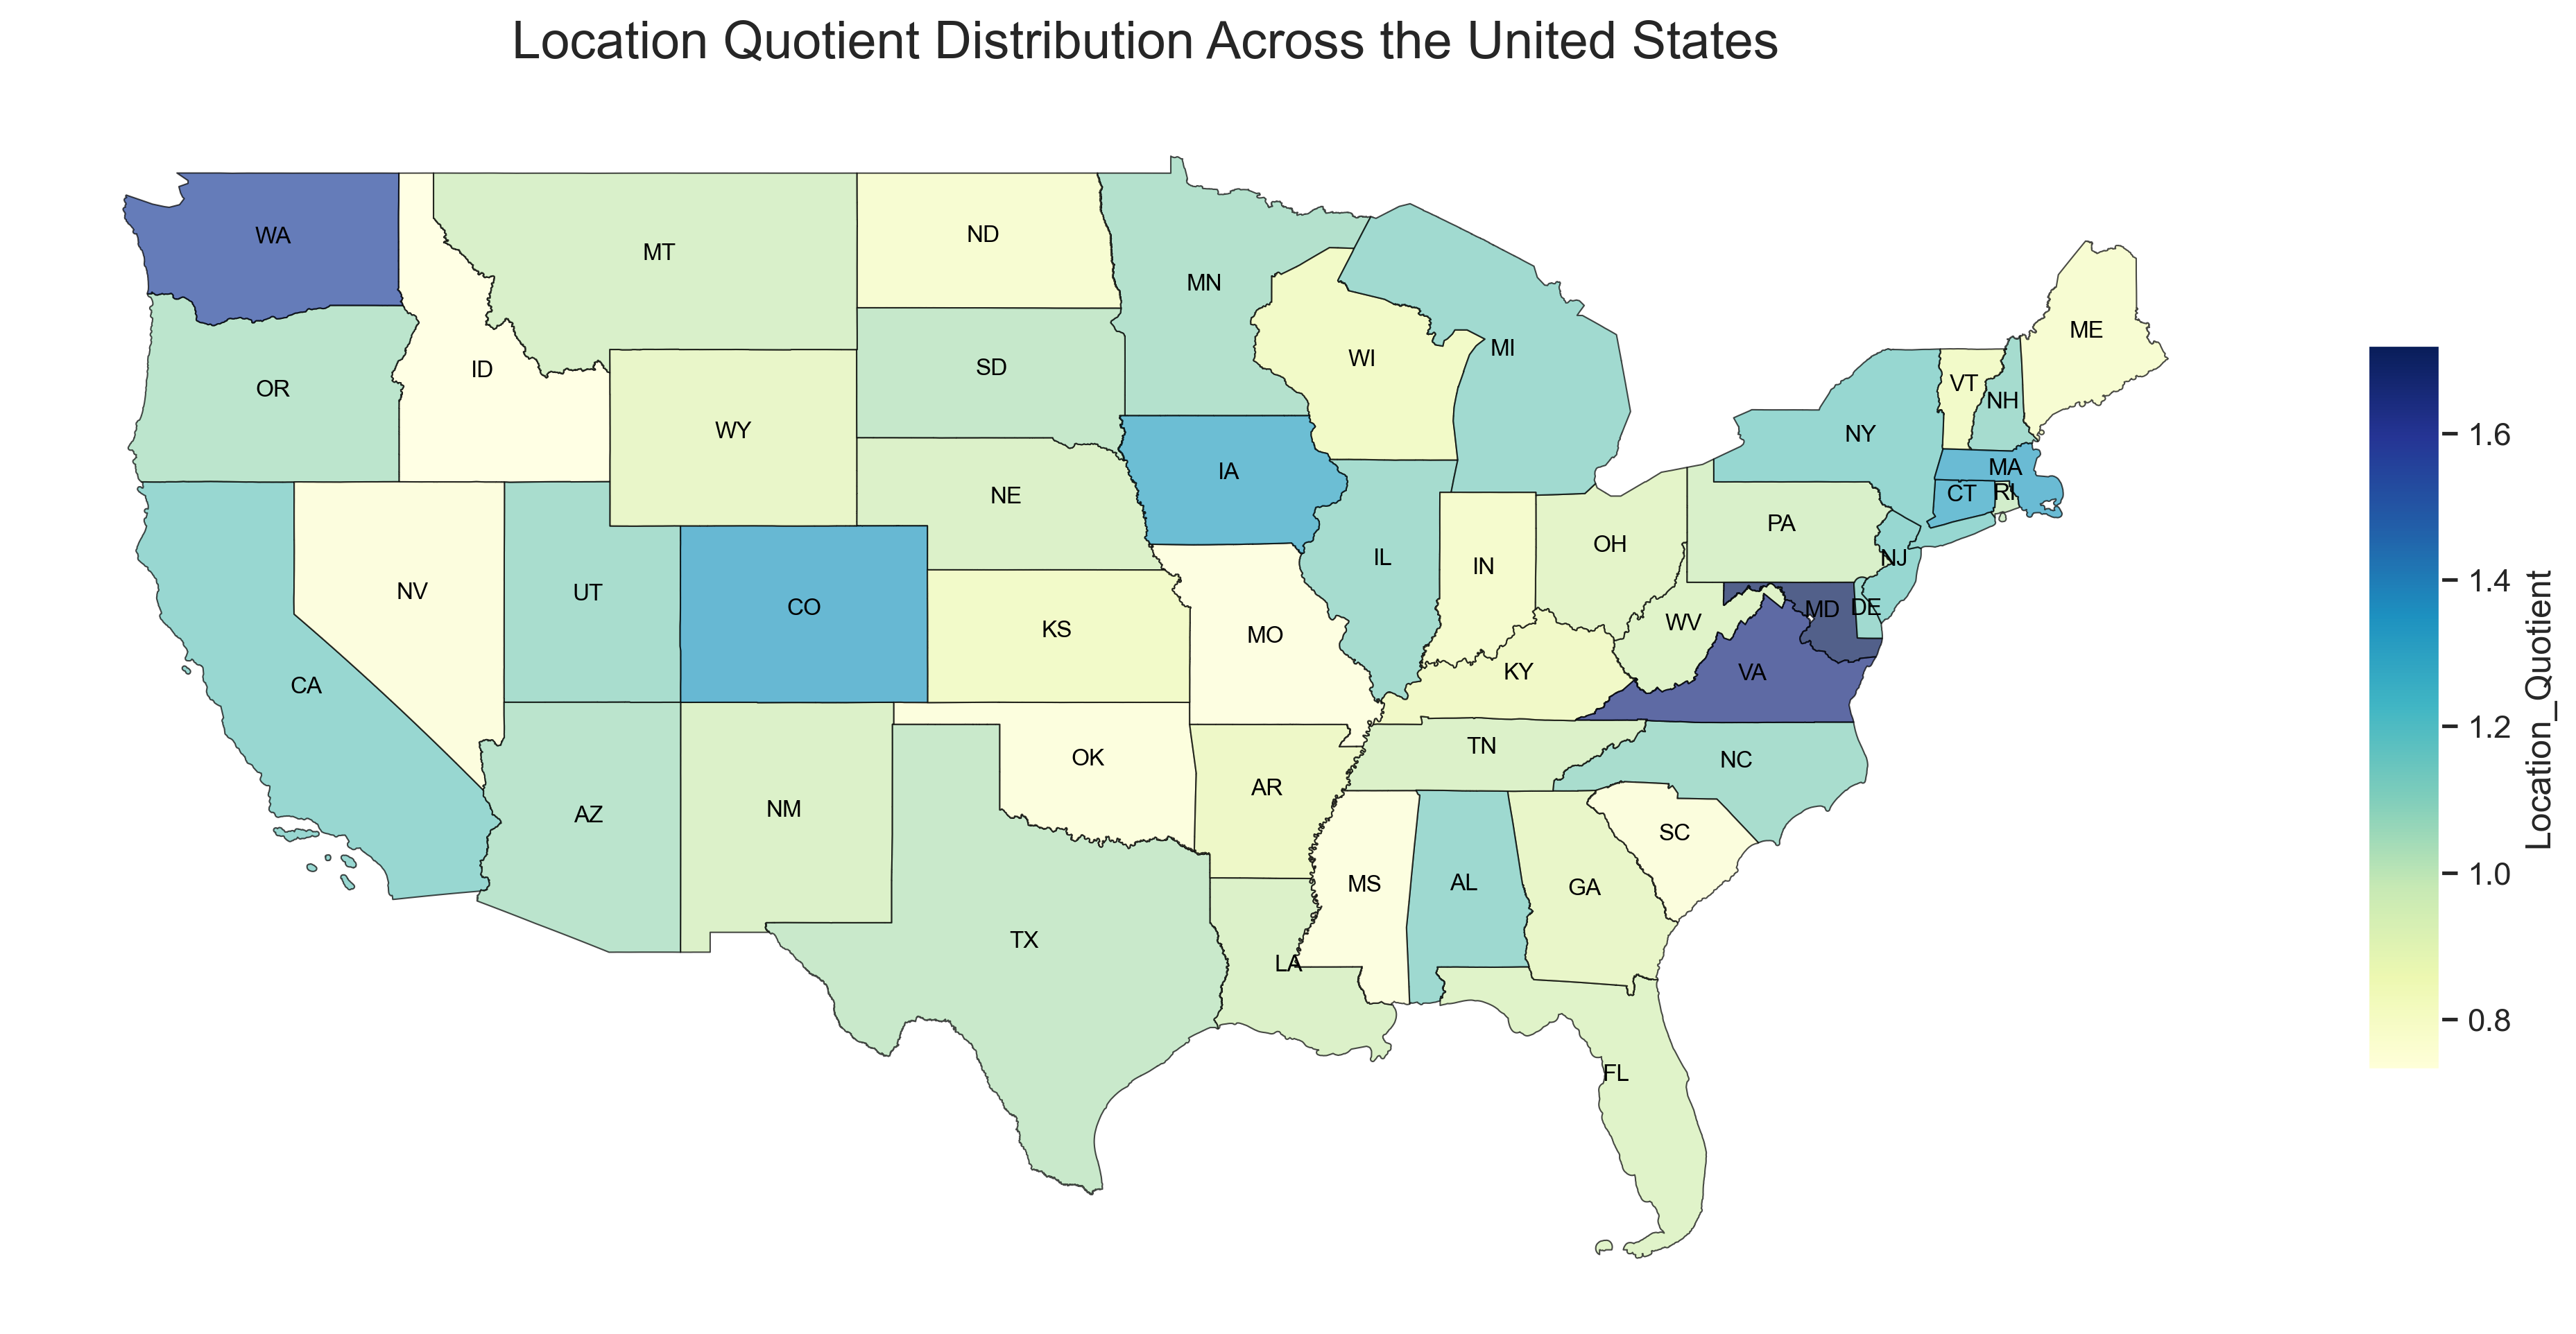

In [67]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='Location_Quotient',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='Location Quotient Distribution Across the United States',
    filename='High_Paying_Jobs_LQ_Distribution.png',
    edge_color='black'
)

### Question 3: What is the dominant education level for high-paying jobs (earning $100K+) across different states, and how does this reflect regional job market demands?

In [68]:
# Data Preparation
dominant_education = (
    high_pay_data.groupby(['State Abbreviation', 'Education Level'])
    .size()
    .reset_index(name='Count')
)
# Sort by state and count, descending, and pick the dominant education
dominant_education = dominant_education.sort_values(
    ['State Abbreviation', 'Count'], ascending=[True, False]
).drop_duplicates(subset='State Abbreviation', keep='first')

# Merge with us_states GeoDataFrame for visualization
geo_dominant_education = pd.merge(
    us_states, dominant_education, left_on='STUSPS', right_on='State Abbreviation', how='left'
)

In [69]:
# Ensure `geo_dominant_education` is a GeoDataFrame for spatial plotting
geo_dominant_education = gpd.GeoDataFrame(geo_dominant_education, geometry='geometry')
# exclude ALska and huwaii
geo_dominant_education=geo_dominant_education.loc[~geo_dominant_education['STUSPS'].isin(['AK', 'HI'])]

#### Visualization 

Map successfully saved to Images\Dominant_education_by_state.png


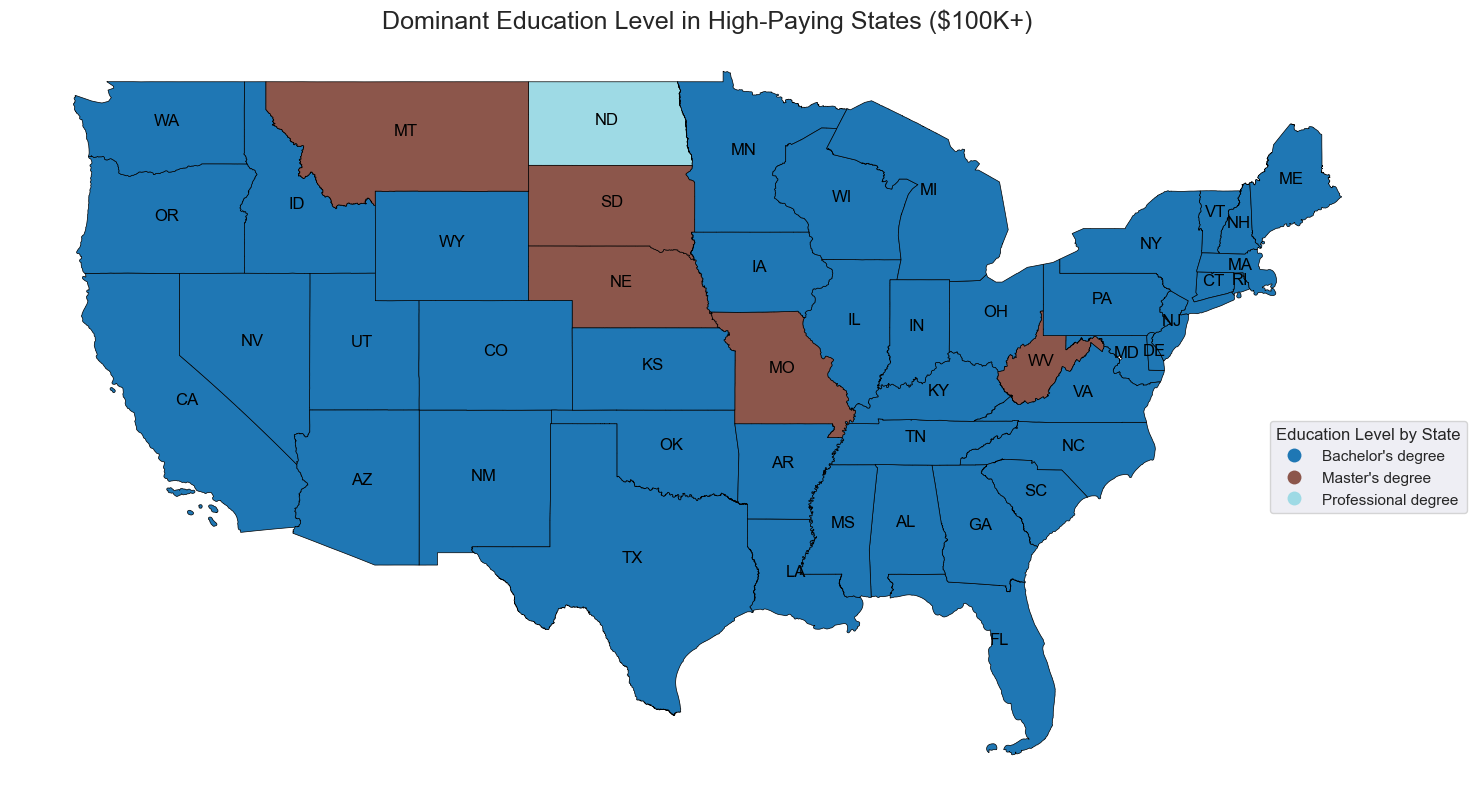

In [80]:
#Ploting  Results
# Function call with your data and specifications
Education_State(geo_dominant_education, 'Education Level', 
                'Dominant Education Level in High-Paying States ($100K+)', 
                'Dominant_education_by_state.png')


### Question 4: What is the gender distribution in high-paying jobs ($100K+) across different states?


#### Data Preparation

In [72]:
# Step 1: Filter and Aggregate the Data
# Group by State and Gender to get counts
gender_counts = high_pay_data.groupby(['State Abbreviation', 'Gender']).size().unstack(fill_value=0)

# Step 2: Calculate Percentages
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['Male_Percentage'] = (gender_counts['Male'] / gender_counts['Total']) * 100
gender_counts['Female_Percentage'] = (gender_counts['Female'] / gender_counts['Total']) * 100

# Reset index to have State as a column
gender_counts.reset_index(inplace=True)

# Step 3: Merge with Geographical Data
geo_gender_df = us_states.merge(gender_counts, left_on='STUSPS', right_on='State Abbreviation', how='left')


In [73]:
#exclude ak and hi
geo_gender_df = geo_gender_df.loc[~geo_gender_df['STUSPS'].isin(['AK', 'HI'])]
# drop bad rows
geo_gender_df=geo_gender_df.dropna(how='any')

#### Visualization 

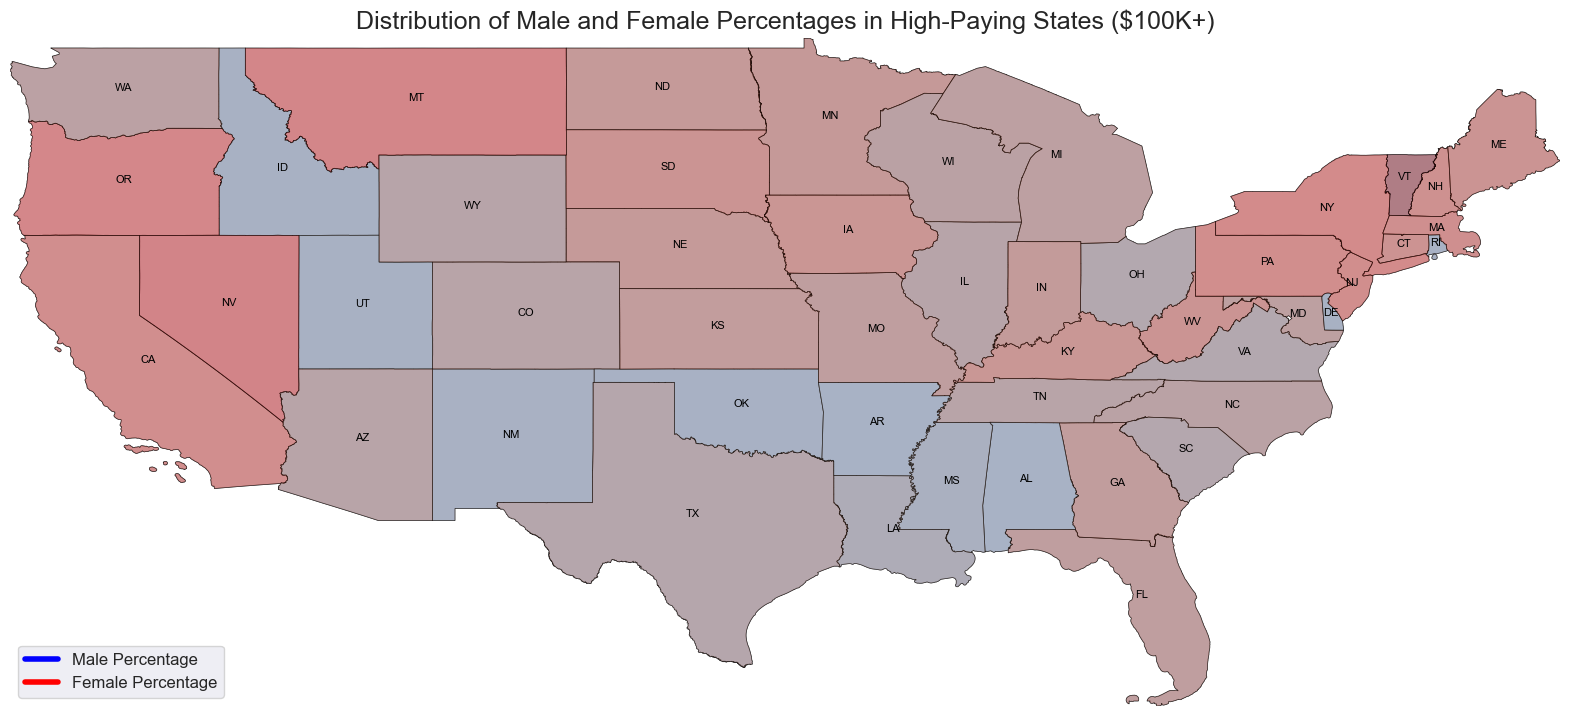

In [75]:
# Call the function to plot the gender distribution
plot_gender_distribution(geo_gender_df)